In [1]:
import pandas
import matplotlib.pyplot as plt
import hddm
import numpy as np
from pandas import Series
import sys
import os
import seaborn as sns

from kabuki.analyze import check_geweke
from patsy import dmatrix

print(hddm.__version__)
os.getcwd()

0.8.0


/Users/ivar/opt/anaconda3/envs/pyHDDM/lib/python3.6/site-packages/IPython/parallel.py:13: ShimWarning: The `IPython.parallel` package has been deprecated since IPython 4.0. You should import from ipyparallel instead.
  "You should import from ipyparallel instead.", ShimWarning)


'/Users/ivar'

In [9]:
cd='/Users/ivar/Documents/RTrules/'
os.chdir(cd)
data = hddm.load_csv('flanker_clean.csv',delimiter = ',')

In [10]:
# filter
data.rename(columns = {'subj_code':'subj_idx'}, inplace = True)
data['rt'] = data['rt']/1000
data = data[data['rt'] > 0.2]
data = data[data['rt'] < 3]

In [11]:
summary = data.groupby(['stim_type']).agg(
    mean_rt=('rt', 'median'),
    mean_accuracy=('response', 'mean')
).reset_index()

print(summary)

     stim_type  mean_rt  mean_accuracy
0    Congruent   0.5290       0.981224
1  Incongruent   0.5895       0.928147


In [12]:
data

,subj_idx,block,stim_type,response,rt
0,RoqXsdd7kmV0,1,Incongruent,1,0.985
1,RoqXsdd7kmV0,1,Congruent,1,0.658
2,RoqXsdd7kmV0,1,Incongruent,1,0.618
3,RoqXsdd7kmV0,1,Congruent,1,0.866
4,RoqXsdd7kmV0,1,Incongruent,1,0.573
...,...,...,...,...,...
28891,Mgt6phKwTSCZ,4,Incongruent,1,0.546
28892,Mgt6phKwTSCZ,4,Congruent,1,0.468
28893,Mgt6phKwTSCZ,4,Incongruent,1,0.571
28894,Mgt6phKwTSCZ,4,Incongruent,1,0.602


In [13]:
#data.loc[data['correct'] == True, 'response'] = 1
#data.loc[data['correct'] == False, 'response'] = 0

print(data['subj_idx'].nunique())

301


In [23]:
#%%
################
# MODEL 1 FLANKER
################
model_name = 'model2flanker'
samples = 5000

# os.mkdir(cd + '/' + model_name)
os.chdir(cd + '/' + model_name)

data['conflict'] = data['stim_type'] == 'Incongruent'                                   
test_model = hddm.HDDM(data, include=('v', 'a', 't'), p_outlier=.05,
                       depends_on={'v': ['conflict', 'block'],
                                   't': ['block'],
                                   'a': ['block']})

/Users/ivar/opt/anaconda3/envs/pyHDDM/lib/python3.6/site-packages/scipy/optimize/optimize.py:2116: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


 [-----------------100%-----------------] 5001 of 5000 complete in 82644.2 secPlotting t(1)
Plotting t(2)
Plotting t(3)
Plotting t(4)
Plotting v(1.False)
Plotting v(1.True)
Plotting v(2.False)
Plotting v(2.True)
Plotting v(3.False)
Plotting v(3.True)
Plotting v(4.False)
Plotting v(4.True)
Plotting a(1)
Plotting a(2)
Plotting a(3)
Plotting a(4)


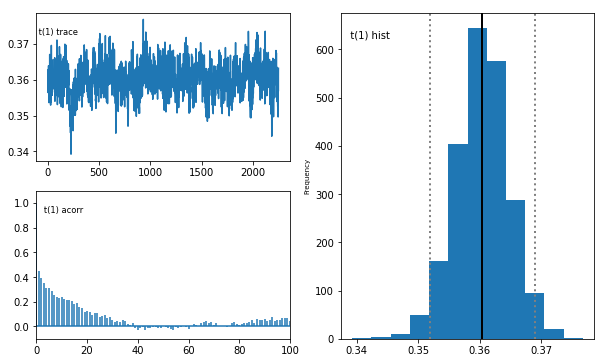

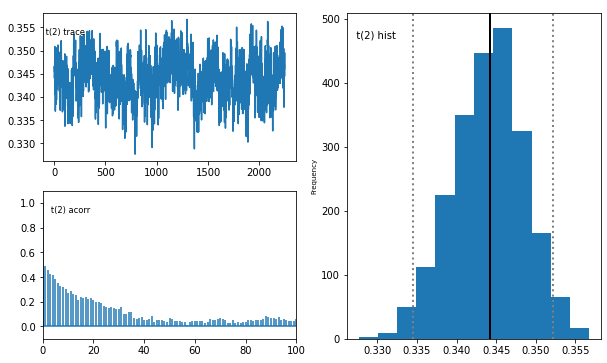

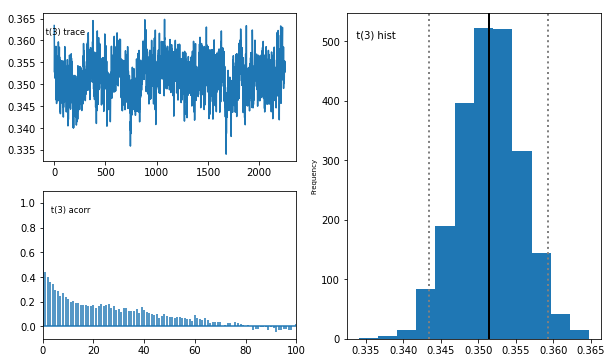

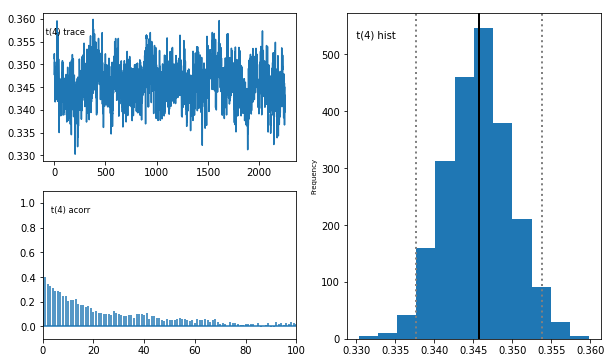

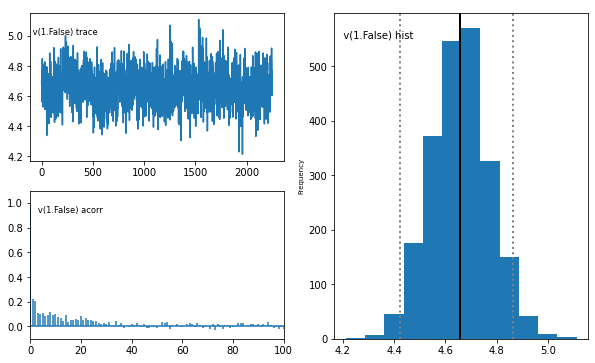

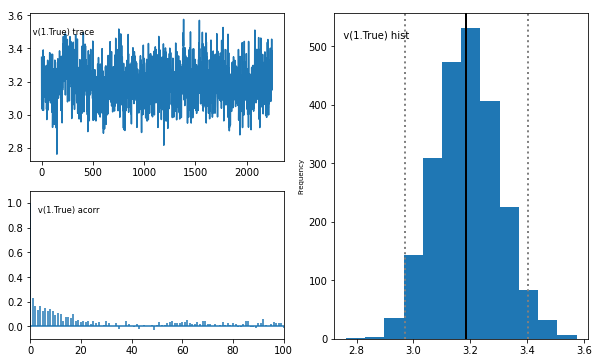

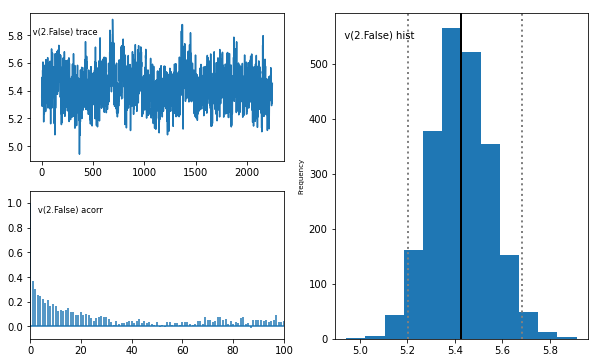

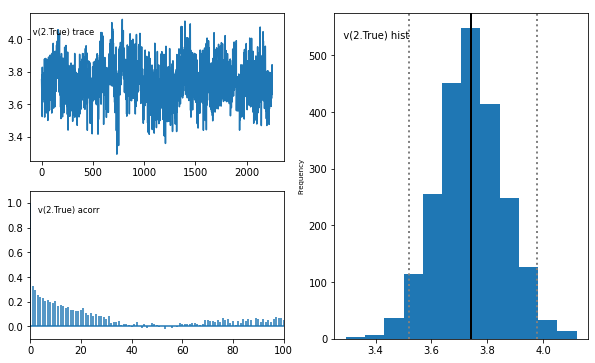

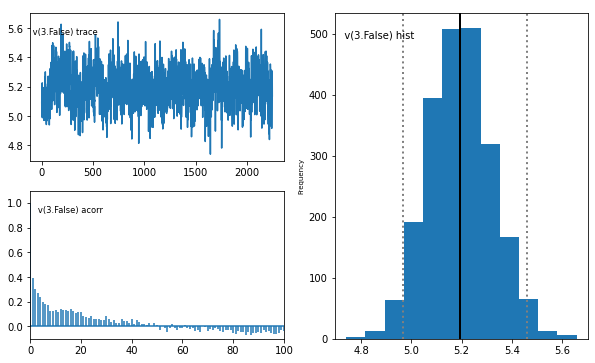

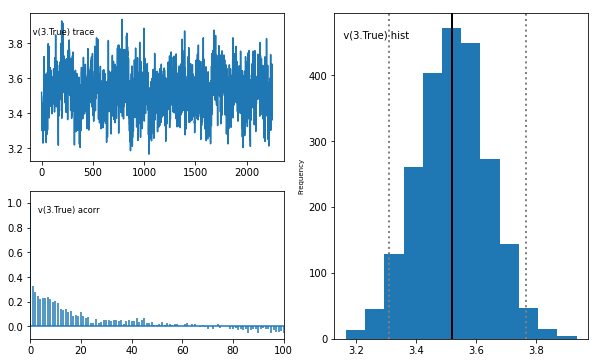

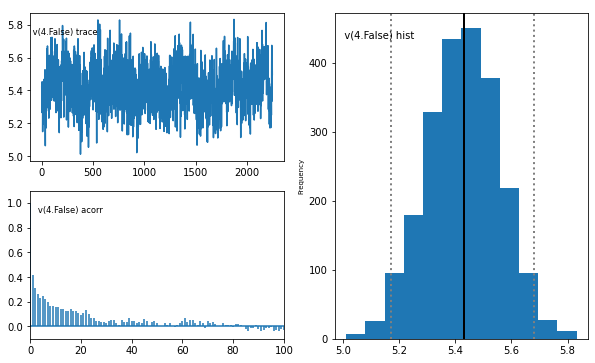

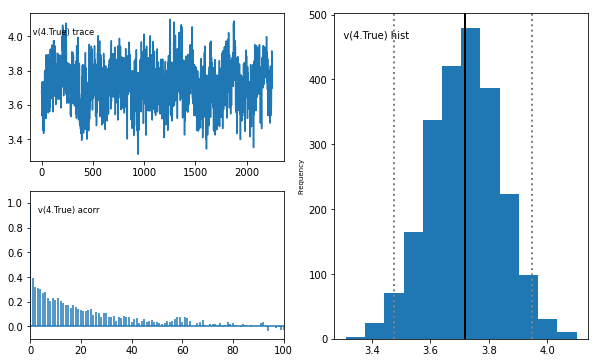

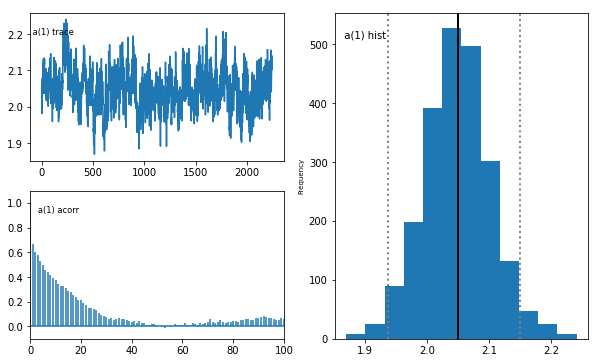

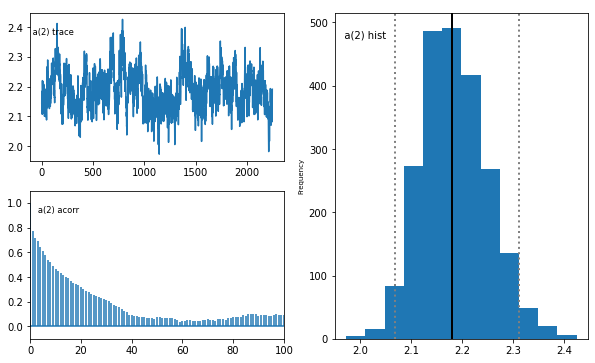

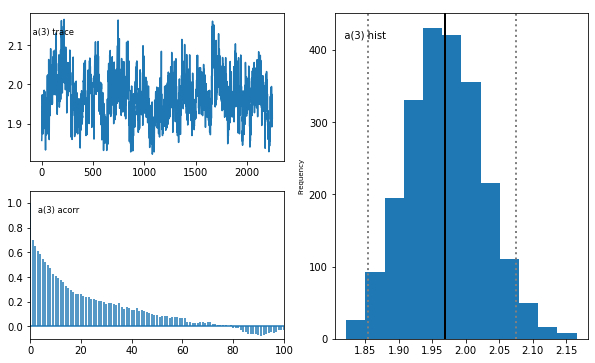

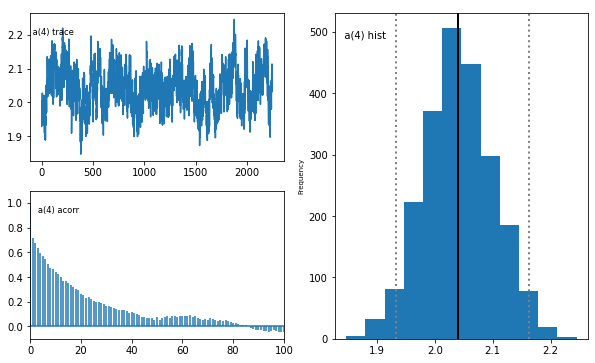

In [25]:
test_model.find_starting_values()
test_model.sample(samples, burn=samples/10, thin=2, dbname=os.path.join(cd, model_name, model_name + '_trace'), db='pickle')
test_model.save(model_name)
test_model.print_stats(model_name + '_dic.txt')
test_model_output = test_model.gen_stats()
test_model_output.to_csv(model_name + '_output.csv')

test_model.plot_posteriors(['t'], save=True)
test_model.plot_posteriors(['v'], save=True)
test_model.plot_posteriors(['a'], save=True)
# test_model.plot_posteriors(['z'], save=True)


# get traces to retrieve posterior distributions
test_model = hddm.load(model_name)
results = test_model.get_traces()
results.to_csv(model_name + '_within_traces.csv')


In [26]:
cd='/Users/ivar/Documents/RTrules/'
os.chdir(cd)

In [27]:
data2 = hddm.load_csv('stroop_clean.csv',delimiter = ',')
data2.rename(columns = {'subj_code':'subj_idx'}, inplace = True)
# filter
data2['rt'] = data2['rt']/1000
data2 = data2[data2['rt'] > 0.2]
data2 = data2[data2['rt'] < 5] 

In [38]:
data2['conflict'] = data2['stim_type'] == "Incongruent"  
data2

,subj_idx,block,stim_type,response,rt,conflict
0,RoqXsdd7kmV0,1,Congruent,1,1.064,False
1,RoqXsdd7kmV0,1,Incongruent,1,1.071,True
2,RoqXsdd7kmV0,1,Congruent,1,0.948,False
3,RoqXsdd7kmV0,1,Incongruent,1,1.103,True
4,RoqXsdd7kmV0,1,Congruent,1,0.929,False
...,...,...,...,...,...,...
28891,Mgt6phKwTSCZ,4,Incongruent,1,0.713,True
28892,Mgt6phKwTSCZ,4,Congruent,1,0.740,False
28893,Mgt6phKwTSCZ,4,Incongruent,1,0.876,True
28894,Mgt6phKwTSCZ,4,Incongruent,1,1.027,True


In [39]:
summary = data2.groupby(['stim_type']).agg(
    mean_rt=('rt', 'median'),
    mean_accuracy=('response', 'mean')
).reset_index()

print(summary)

     stim_type  mean_rt  mean_accuracy
0    Congruent    0.859       0.992901
1  Incongruent    1.039       0.944460


In [40]:
#%%
################
# MODEL 1 FLANKER
################
model_name = 'model2stroop'
samples = 5000

# os.mkdir(cd + '/' + model_name)
os.chdir(cd + '/' + model_name)
                                  
test_model = hddm.HDDM(data2, include=('v', 'a', 't'), p_outlier=.05,
                       depends_on={'v': ['conflict', 'block'],
                                   't': ['block'],
                                   'a': ['block']})

/Users/ivar/opt/anaconda3/envs/pyHDDM/lib/python3.6/site-packages/scipy/optimize/optimize.py:2116: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


 [-----------------100%-----------------] 5001 of 5000 complete in 138338.7 secPlotting t(1)
Plotting t(2)
Plotting t(3)
Plotting t(4)
Plotting v(1.False)
Plotting v(1.True)
Plotting v(2.False)
Plotting v(2.True)
Plotting v(3.False)
Plotting v(3.True)
Plotting v(4.False)
Plotting v(4.True)
Plotting a(1)
Plotting a(2)
Plotting a(3)
Plotting a(4)


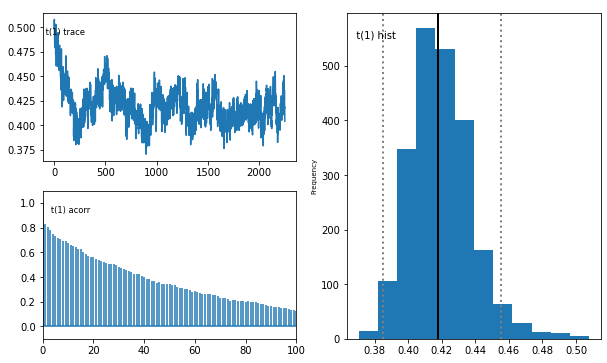

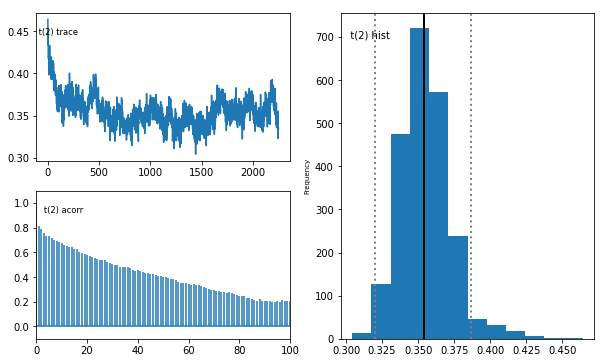

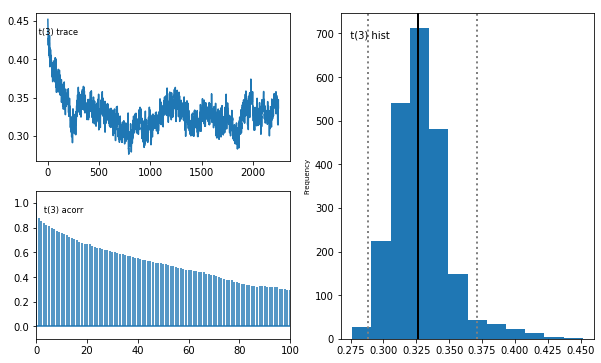

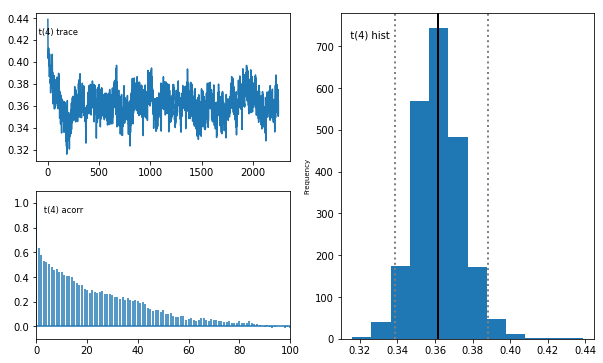

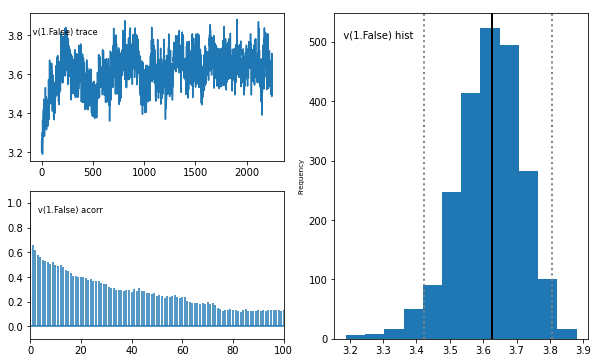

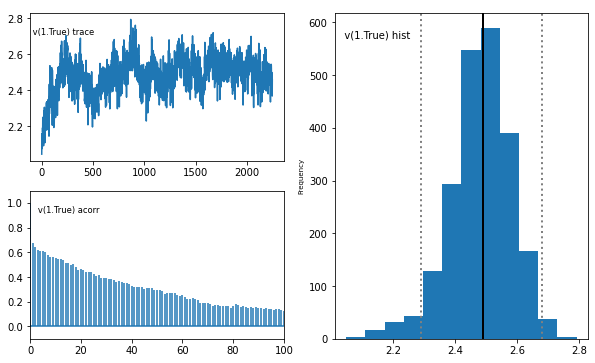

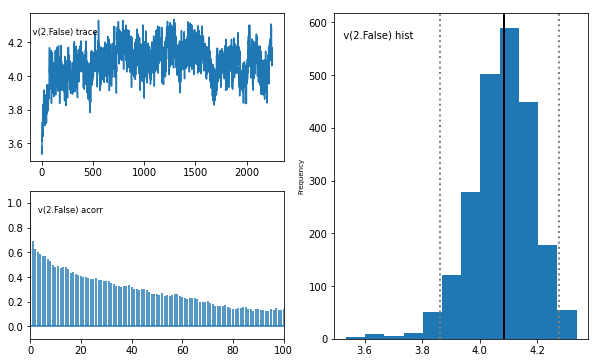

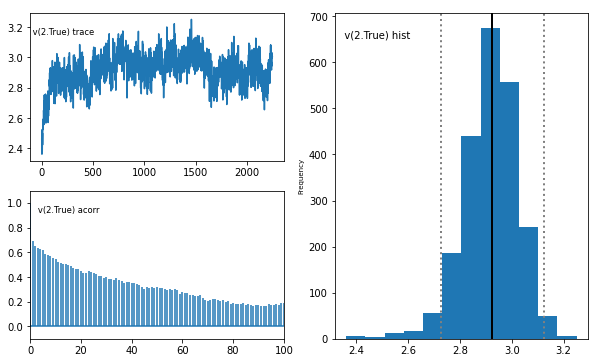

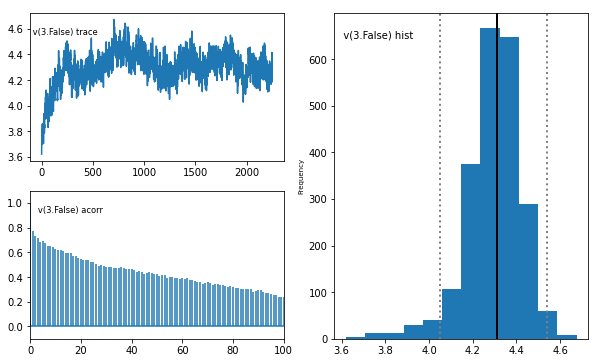

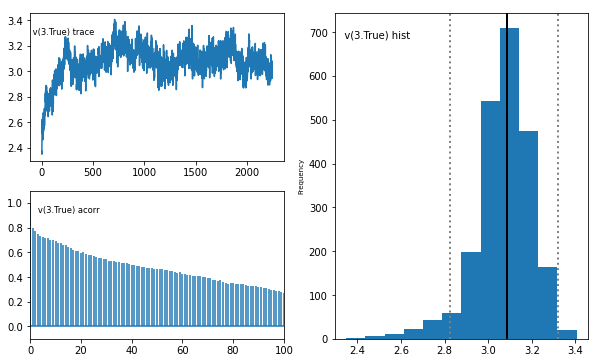

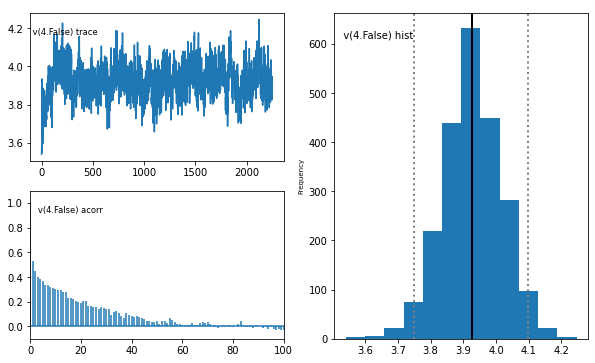

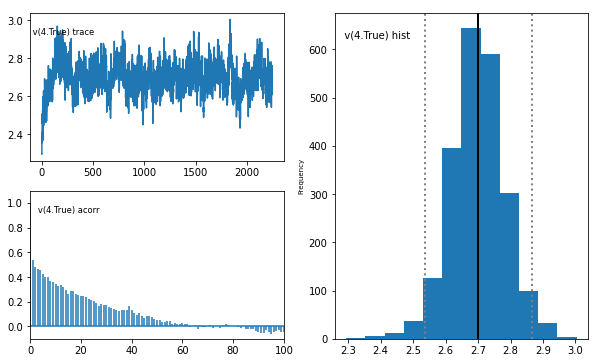

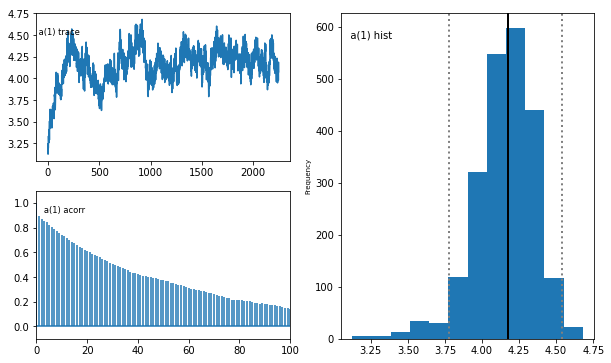

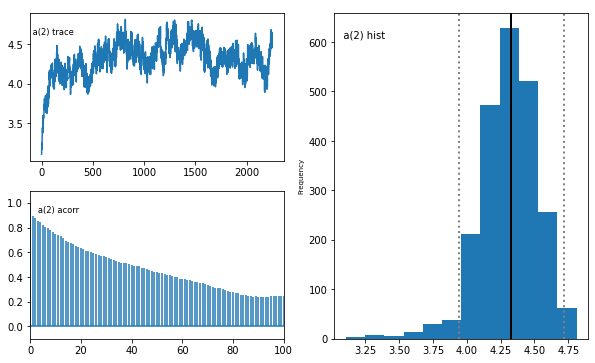

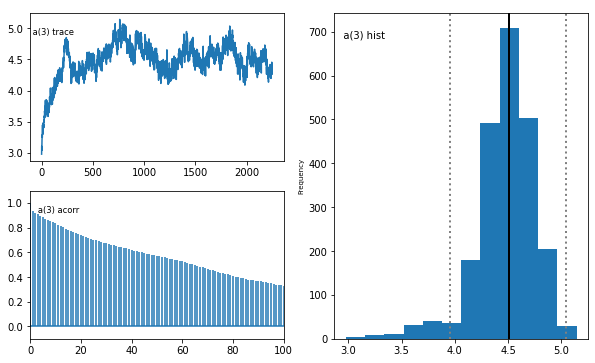

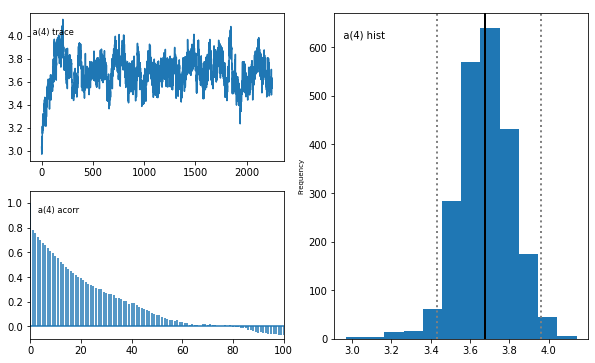

In [41]:
test_model.find_starting_values()
test_model.sample(samples, burn=samples/10, thin=2, dbname=os.path.join(cd, model_name, model_name + '_trace'), db='pickle')
test_model.save(model_name)
test_model.print_stats(model_name + '_dic.txt')
test_model_output = test_model.gen_stats()
test_model_output.to_csv(model_name + '_output.csv')

test_model.plot_posteriors(['t'], save=True)
test_model.plot_posteriors(['v'], save=True)
test_model.plot_posteriors(['a'], save=True)
# test_model.plot_posteriors(['z'], save=True)


# get traces to retrieve posterior distributions
test_model = hddm.load(model_name)
results = test_model.get_traces()
results.to_csv(model_name + '_within_traces.csv')

In [49]:
cd='/Users/ivar/Documents/RTrules/'
os.chdir(cd)

data = hddm.load_csv('rules_clean.csv',delimiter = ',')
data.rename(columns = {'subj_code':'subj_idx'}, inplace = True)
# filter
data['rt'] = data['rt']/1000
data = data[data['rt'] > 0.4]
data = data[data['rt'] < 6]
data

,subj_idx,block,text,purpose,response,rt
1,RoqXsdd7kmV0,1,1,0,1.0,2.378
3,RoqXsdd7kmV0,1,1,0,1.0,3.478
4,RoqXsdd7kmV0,1,0,0,0.0,2.362
5,RoqXsdd7kmV0,1,0,1,0.0,2.058
6,RoqXsdd7kmV0,1,1,1,1.0,2.054
...,...,...,...,...,...,...
28891,Mgt6phKwTSCZ,4,0,0,1.0,2.016
28892,Mgt6phKwTSCZ,4,0,0,0.0,2.220
28893,Mgt6phKwTSCZ,4,1,0,0.0,3.046
28894,Mgt6phKwTSCZ,4,0,0,0.0,2.388


In [50]:
data['conflict'] = data['text'] != data['purpose']

summary = data.groupby(['text', 'purpose']).agg(
    mean_rt=('rt', 'median'),
    mean_accuracy=('response', 'mean')
).reset_index()

print(summary)

   text  purpose  mean_rt  mean_accuracy
0     0        0    2.274       0.054658
1     0        1    2.671       0.226892
2     1        0    2.926       0.701602
3     1        1    2.281       0.930570


In [51]:
data['violation'] = data['response'] 
# Conditionally update response column based on text and response2 columns
data.loc[data['text'] == data['violation'], 'response'] = 1
data.loc[data['text'] != data['violation'], 'response'] = 0

summary = data.groupby(['text', 'purpose']).agg(
    mean_rt=('rt', 'median'),
    mean_accuracy=('response', 'mean')
).reset_index()

print(summary)

   text  purpose  mean_rt  mean_accuracy
0     0        0    2.274       0.945342
1     0        1    2.671       0.773108
2     1        0    2.926       0.701602
3     1        1    2.281       0.930570


In [52]:
#%%
################
# MODEL 2
################
model_name = 'model4rulesFS'
samples = 5000

# os.mkdir(cd + '/' + model_name)
os.chdir(cd + '/' + model_name)

test_model = hddm.HDDM(data, include=('v', 'a', 't', 'z'),  
                      depends_on={'v': ['conflict', 'block'],
                                 'a': ['block'],
                                 't': ['block']}, 
                      p_outlier=.05)
                                   

/Users/ivar/opt/anaconda3/envs/pyHDDM/lib/python3.6/site-packages/scipy/optimize/optimize.py:2116: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


 [-----------------100%-----------------] 5001 of 5000 complete in 145293.9 secPlotting t(1)
Plotting t(2)
Plotting t(3)
Plotting t(4)
Plotting v(1.False)
Plotting v(1.True)
Plotting v(2.False)
Plotting v(2.True)
Plotting v(3.False)
Plotting v(3.True)
Plotting v(4.False)
Plotting v(4.True)
Plotting a(1)
Plotting a(2)
Plotting a(3)
Plotting a(4)


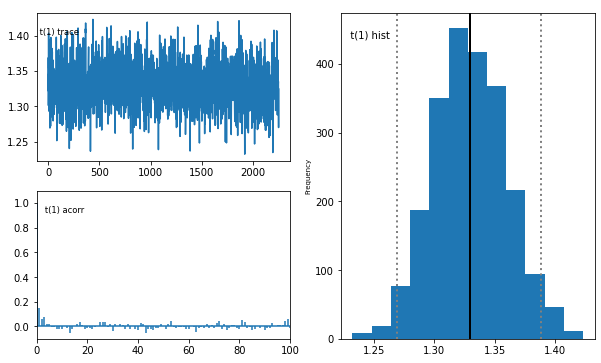

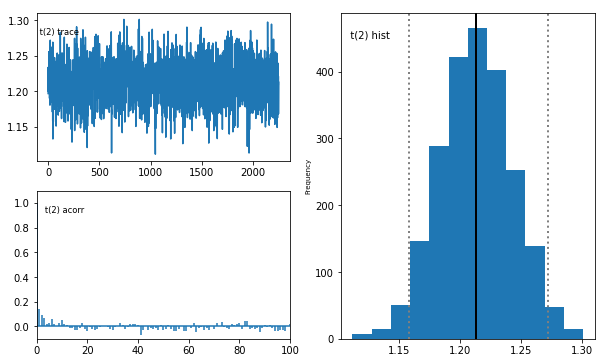

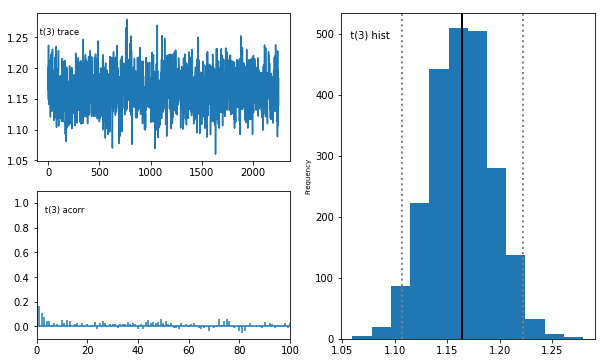

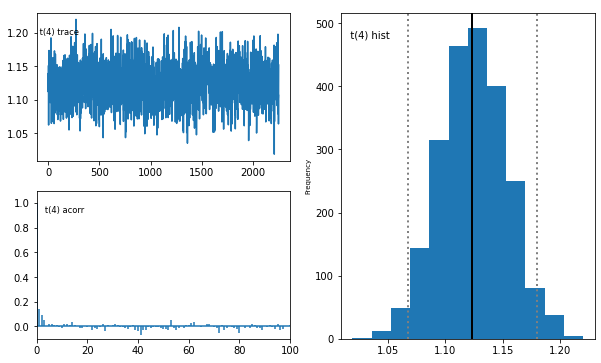

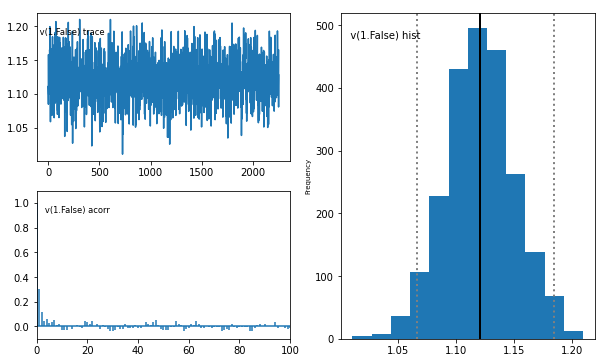

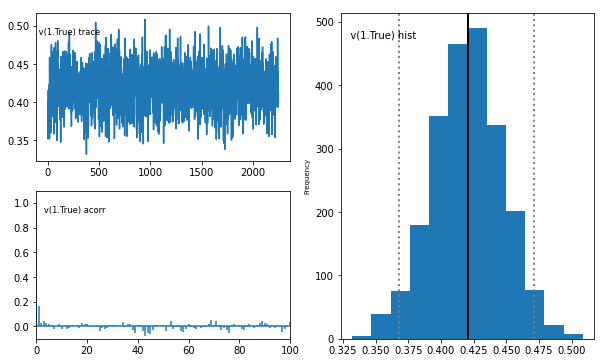

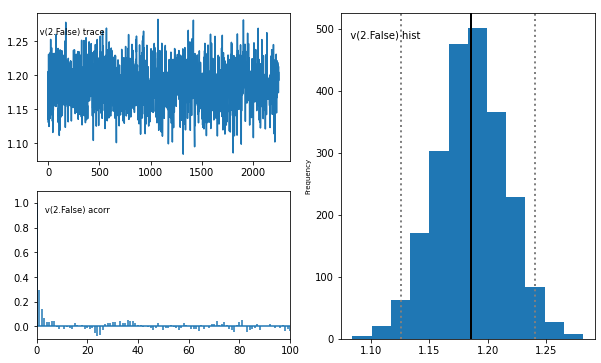

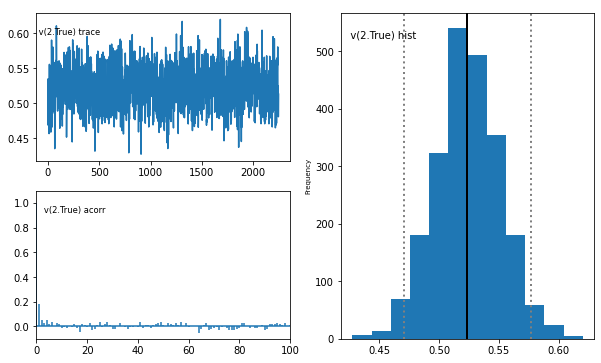

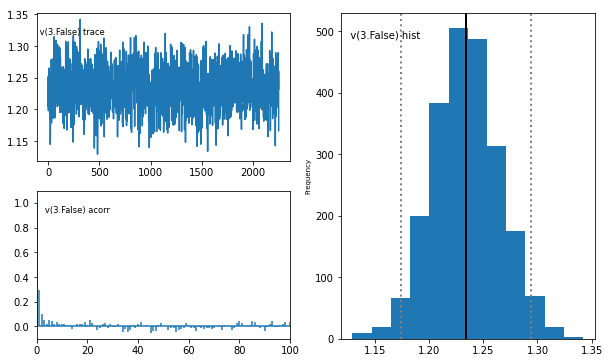

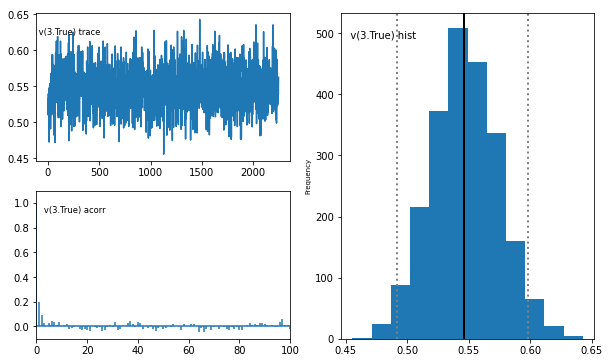

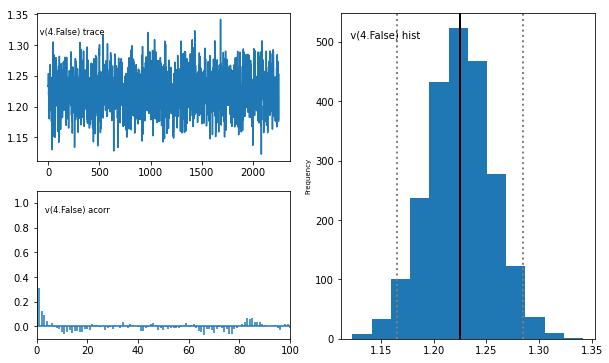

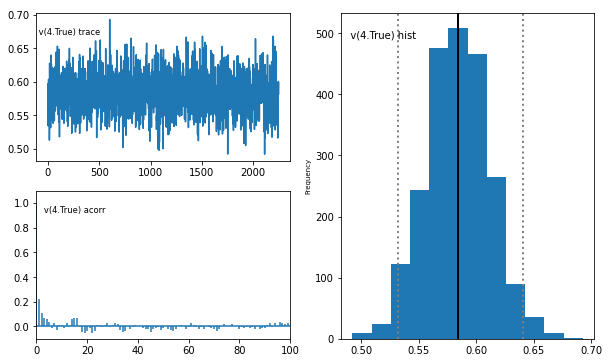

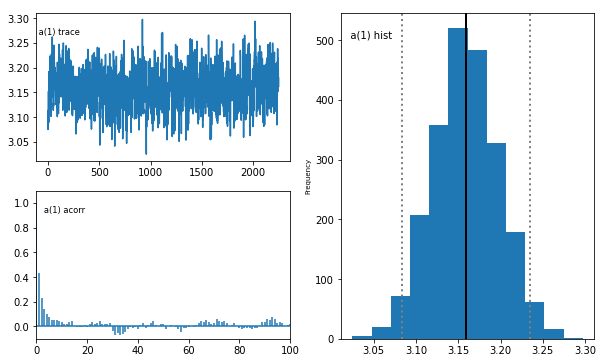

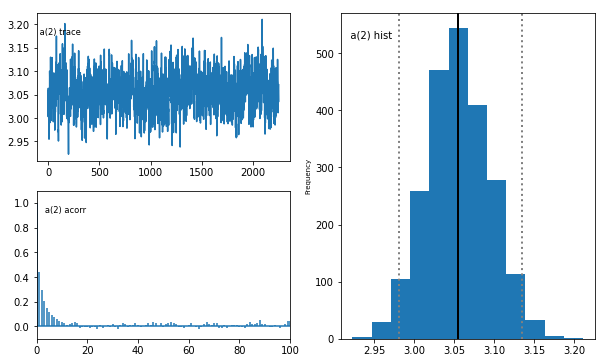

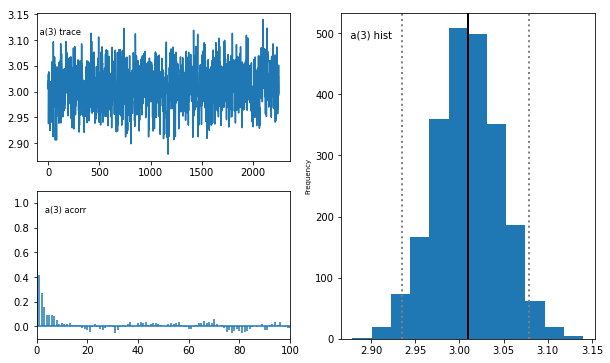

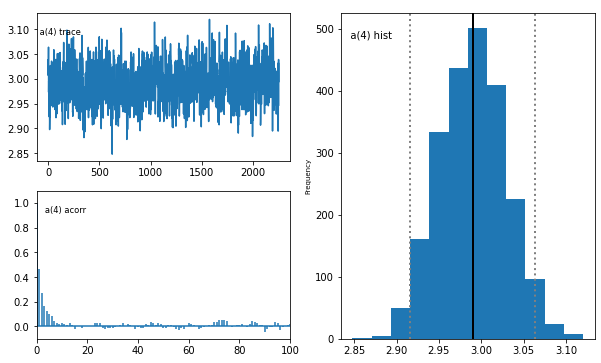

In [53]:
test_model.find_starting_values()
test_model.sample(samples, burn=samples/10, thin=2, dbname=os.path.join(cd, model_name, model_name + '_trace'), db='pickle')
test_model.save(model_name)
test_model.print_stats(model_name + '_dic.txt')
test_model_output = test_model.gen_stats()
test_model_output.to_csv(model_name + '_output.csv')

test_model.plot_posteriors(['t'], save=True)
test_model.plot_posteriors(['v'], save=True)
test_model.plot_posteriors(['a'], save=True)
# test_model.plot_posteriors(['z'], save=True)


# get traces to retrieve posterior distributions
test_model = hddm.load(model_name)
results = test_model.get_traces()
results.to_csv(model_name + '_within_traces.csv')
